# **CODA (v2.0.0) Tutorial 2 — Computing the Spatial Cross-Correlation Index**

> **Goal of Tutorial 2**: Compute the spatial cross-correlation index (CCI) on the aligned artery and mouse brain datasets.

## **Environment setup & imports**

In [1]:
from CODA.Alignment import *
from CODA.Preprocessing import *
from CODA.RGBgenerator import *
from CODA.utils import *
from CODA.Cross_correlation import *
from CODA.Common_domain import *

D:\Anaconda\envs\CODA_test\lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## **Dataset 1. Human Artery**
* You can download the data required for this tutorial here: [Example data 2](<https://drive.google.com/drive/folders/1Z6q2jla5X5-KpZPqdVDOuNwekIZuNcJQ?usp=drive_link>).

* After downloading, place the files in the same directory as this notebook (`Tutorial 2 (Spatial Cross-Correlation).ipynb`).

In [2]:
CAD = sc.read_h5ad('CAD.h5ad')
normal = sc.read_h5ad('normal.h5ad')

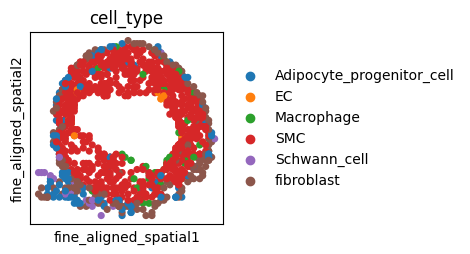

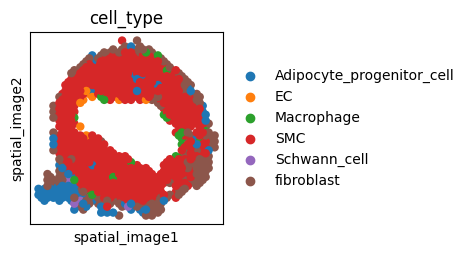

In [3]:
plt.rcParams['figure.figsize'] = (2.5,2.5)
sc.pl.embedding(CAD, basis='fine_aligned_spatial', color='cell_type')
sc.pl.embedding(normal, basis='spatial_image', color='cell_type')

### Compute the Cross-Correlation between aligned slices

In [4]:
scc = SpatialCrossCorrelation(normal, CAD,
                              coord_key_1='spatial_image',
                              coord_key_2='fine_aligned_spatial',
                              beta=1.0)

results = scc.compute_cross_correlation()

In [5]:
for gene, score in results[:20]:
    print(f"{gene}\t{score:.4f}")

MYL9	0.3491
TAGLN	0.3472
ACTA2	0.2583
APOD	0.2490
CFD	0.2440
FN1	0.2402
TPM2	0.2201
FLNA	0.2148
MYH11	0.2131
G0S2	0.1979
DCN	0.1927
C7	0.1907
LINC00632	0.1905
MGST1	0.1772
FABP4	0.1743
AEBP1	0.1662
SERPINF1	0.1659
DSTN	0.1617
AL161421.1	0.1589
PLIN4	0.1588


### Example of SCG and SDG

* SCG (MYL9)

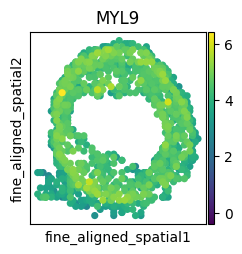

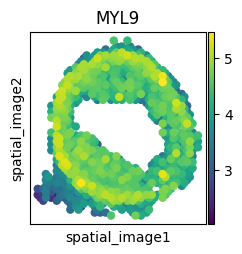

In [6]:
plt.rcParams['figure.figsize'] = (2.5,2.5)
sc.pl.embedding(CAD, basis='fine_aligned_spatial', color='MYL9')
sc.pl.embedding(normal, basis='spatial_image', color='MYL9')

* SDG (CCL2)

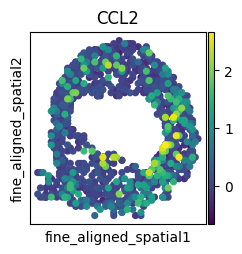

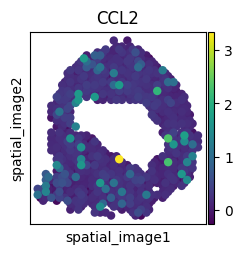

In [7]:
sc.pl.embedding(CAD, basis='fine_aligned_spatial', color='CCL2')
sc.pl.embedding(normal, basis='spatial_image', color='CCL2')

## **Dataset 2. Mouse Brain (Sleep)**

In [8]:
RHY = sc.read_h5ad('rhy.h5ad')
Saline = sc.read_h5ad('saline.h5ad')

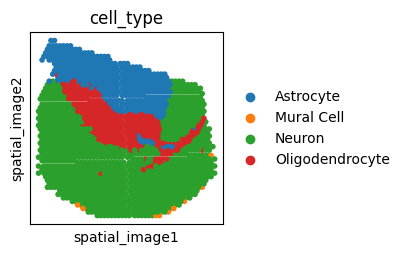

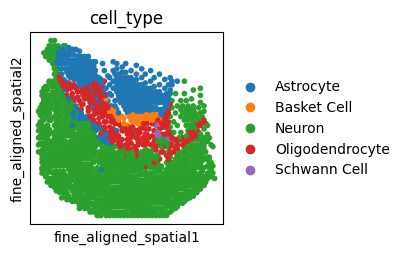

In [9]:
sc.pl.embedding(RHY, basis='spatial_image', color='cell_type')
sc.pl.embedding(Saline, basis='fine_aligned_spatial', color='cell_type')

### Compute the Cross-Correlation between aligned slices

In [10]:
scc = SpatialCrossCorrelation(RHY, Saline,
                              coord_key_1='spatial_image',
                              coord_key_2='fine_aligned_spatial',
                              beta=1.0)

results = scc.compute_cross_correlation()

In [11]:
for gene, score in results[:20]:
    print(f"{gene}\t{score:.4f}")

Stx1a	0.5890
Slc17a7	0.5865
Baiap3	0.5814
Lamp5	0.5789
AW551984	0.5770
Itpka	0.5759
Hpcal4	0.5637
Slc30a3	0.5579
Vxn	0.5526
Ddn	0.5473
Nrgn	0.5404
Hcrt	0.5312
Mef2c	0.5294
Snca	0.5257
Enc1	0.5243
Ngb	0.5206
Igfbp6	0.5203
Tbr1	0.5188
Pmch	0.5130
mt-Atp6	0.5092
